In [ ]:
import numpy as np
import pandas as pd
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
from PIL import Image
import matplotlib.pylab as plot

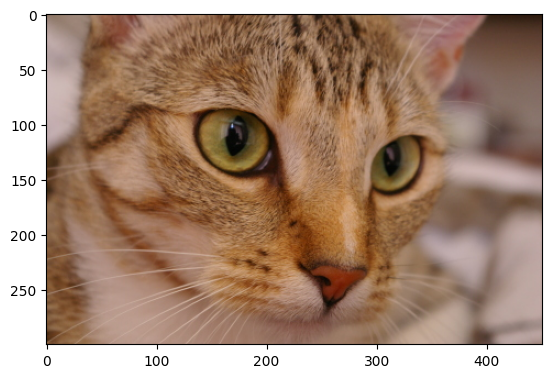

In [ ]:
from skimage import data

thecat = data.chelsea()
plot.imshow(thecat)

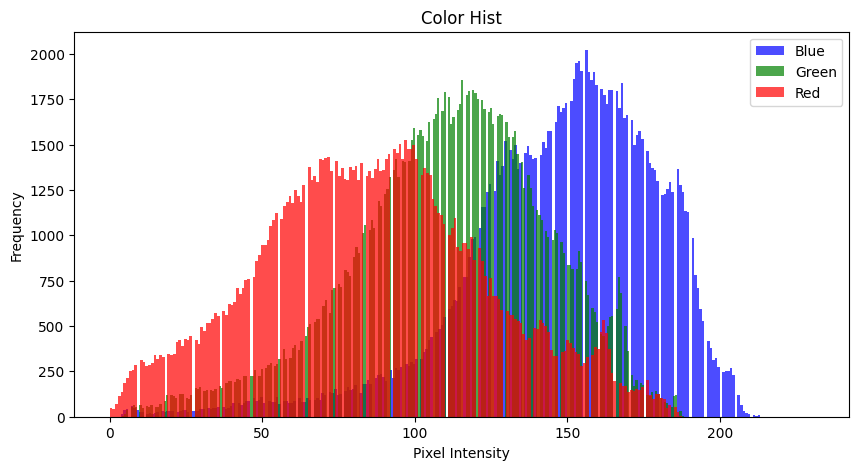

In [ ]:
import cv2
import matplotlib.pyplot as plt
b, g, r = cv2.split(thecat)
plt.figure(figsize=(10,5))
plt.title("Color Hist")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.hist(b.ravel(), bins=256, color='blue', alpha=0.7, label='Blue')
plt.hist(g.ravel(), bins=256, color='green', alpha=0.7, label='Green')

plt.hist(r.ravel(), bins=256, color='red', alpha=0.7, label='Red')

plt.legend()
plt.show()

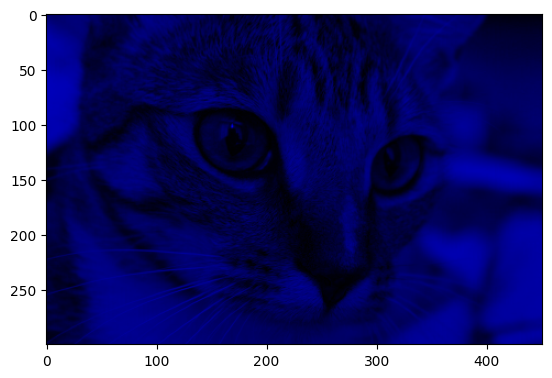

In [ ]:
blue=thecat.copy()
#  Red and Green channel to 0
blue[:,:,0]=0
blue[:,:,1]=0
plot.imshow(blue)

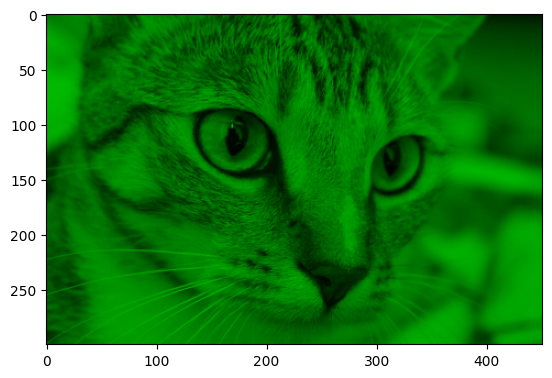

In [ ]:
green=thecat.copy()
#  Red and Blue channel to 0
green[:,:,0]=0
green[:,:,2]=0
plot.imshow(green)

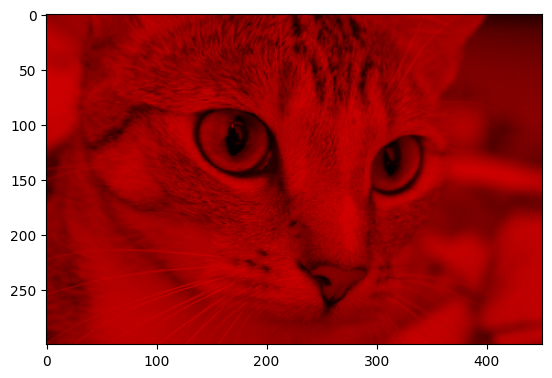

In [ ]:
red=thecat.copy()
#  green and Blue channel to 0
red[:,:,1]=0
red[:,:,2]=0
plot.imshow(red)


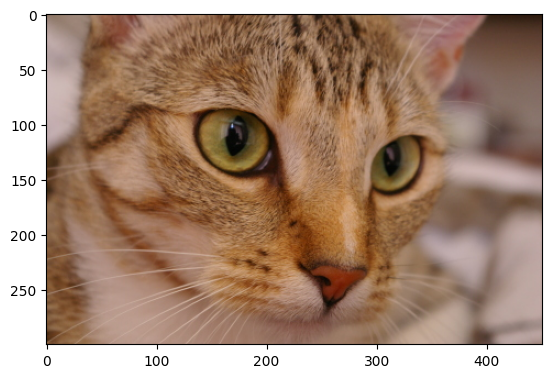

In [ ]:
newcat = red+blue+green
plot.imshow(newcat)

In [ ]:
print('Dimension of cat', np.ndim(thecat))
print('Shape of cat', np.shape(thecat))
print('of New cat')
print('Dimension of cat', np.ndim(newcat))
print('Shape of cat', np.shape(newcat))



Dimension of cat 3
Shape of cat (300, 451, 3)
of New cat
Dimension of cat 3
Shape of cat (300, 451, 3)


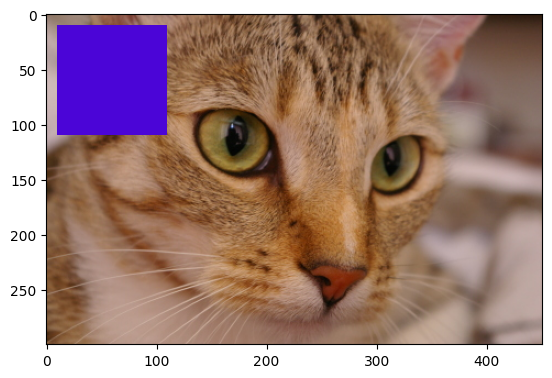

In [ ]:
thecat[10:110, 10:110, :] = [75, 5, 215]  # [red, green, blue]
plot.imshow(thecat);

In [ ]:
## Lets upload image from website
url="https://web.iisermohali.ac.in/dept/physics/QWG2024/img/iisermgate.jpg"
#url="https://surveyofindia.gov.in/documents/polmap-hindi-27-12-2022.jpg"
#url="https://upload.wikimedia.org/wikipedia/commons/thumb/b/b1/Pragyan_rover_deployed_on_the_moon.webp/1200px-Pragyan_rover_deployed_on_the_moon.webp.png"
url="https://www.nasa.gov/wp-content/uploads/2022/07/web_first_images_release.png"
#url="https://science.nasa.gov/wp-content/uploads/2023/09/keyhole-final-2.png"
#url="https://photojournal.jpl.nasa.gov/jpeg/PIA26276.jpg"
myImg = io.imread(url) # 3 dimensional array


In [ ]:
print('Dimension of myImg ', np.ndim(myImg))
print('Shape of myImg', np.shape(myImg))

Dimension of myImg  3
Shape of myImg (1186, 2048, 4)


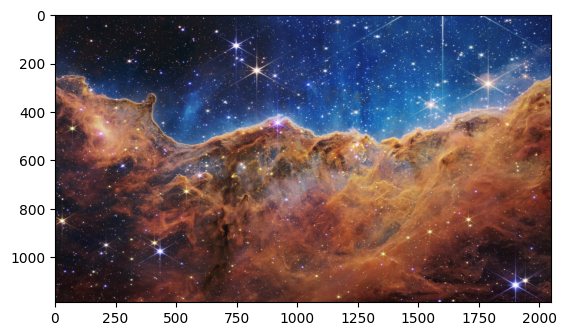

In [ ]:
plot.imshow(myImg)

One expect 3 for RGB but here we have 4 RGBA (Red-Green-Blue-Alpha)

https://www.w3.org/wiki/CSS/Properties/color/RGBA



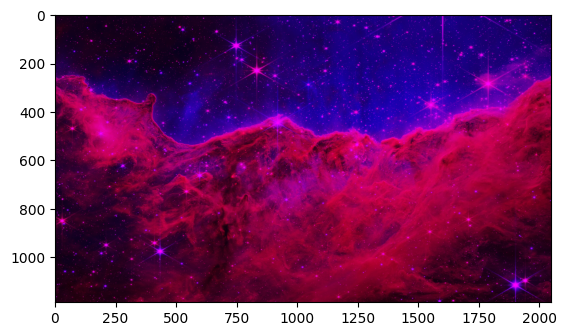

In [ ]:
AA=myImg.copy()
#  Green  to 0
AA[:,:,1]=0
plot.imshow(AA)

In [ ]:
from skimage import img_as_ubyte
cv_image = img_as_ubyte(myImg)

[[22. 22. 22. ... 55. 52. 50.]
 [22. 23. 22. ... 58. 54. 51.]
 [22. 22. 22. ... 51. 50. 48.]
 ...
 [17. 17. 17. ... 30. 28. 27.]
 [16. 17. 17. ... 27. 25. 24.]
 [15. 16. 16. ... 22. 22. 23.]]


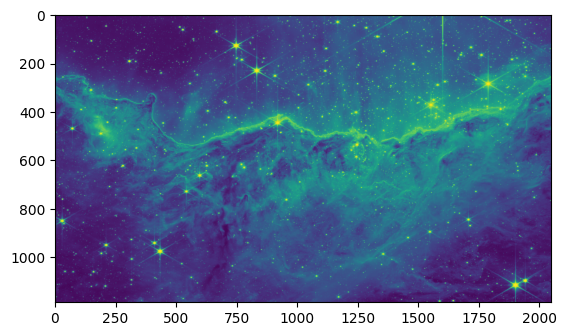

In [ ]:
gray_image = cv.cvtColor(cv_image, cv.COLOR_BGRA2GRAY) # convert 3 dimensional array into 2 dimensional array

img_mat = np.array(list(gray_image), float)

print(img_mat) # pixel value for  gray color image 0 for black and 255 white
img_mat.shape
plot.imshow(img_mat)

In [ ]:
img_mat.shape


(1186, 2048)

As you can see one expect somewhat 1100  singular  values.

1186  rows
2048 column

matrix

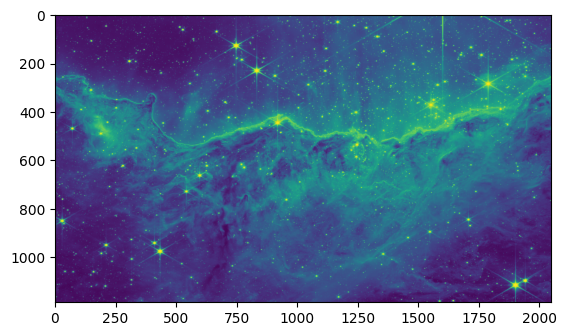

In [ ]:
# scale the image matrix before SVD
img_mat_scaled = (img_mat- img_mat.mean())/img_mat.std()
# Mean become zero and standard deviation become one

plot.imshow(img_mat_scaled)


We wil get the required matrices from numpy linearalgebra

https://numpy.org/doc/stable/reference/generated/numpy.linalg.svd.html


In [ ]:
#Perform SVD using np.linalg.svd
U,s,V = np.linalg.svd(img_mat_scaled)




In [ ]:
print('Dimension of U', np.ndim(U))
print('Shape of U', np.shape(U))
print(' U \n ', U)
print('\n ----\n')
print('Dimension of s', np.ndim(s))
print('Shape of s', np.shape(s))
print(' s \n ', s)
print('\n ----\n')

print('Dimension of V', np.ndim(V))
print('Shape of V', np.shape(V))
print(' \n ', V)


Dimension of U 2
Shape of U (1186, 1186)
 U 
  [[ 0.0135725   0.03986386  0.01926843 ... -0.01289059  0.00178698
  -0.0069844 ]
 [ 0.01411057  0.03932321  0.01931332 ...  0.0091485  -0.00112409
   0.01202534]
 [ 0.01417022  0.04088791  0.0157603  ... -0.00025334 -0.00712468
  -0.00287315]
 ...
 [ 0.04456301  0.01101257 -0.00894439 ... -0.01383241 -0.01327261
   0.00825332]
 [ 0.04533553  0.00959418 -0.00915345 ...  0.00214848  0.01107885
  -0.01320959]
 [ 0.04548799  0.00929703 -0.00868025 ... -0.00865284 -0.01328444
   0.00486714]]

 ----

Dimension of s 1
Shape of s (1186,)
 s 
  [9.72701370e+02 7.11961819e+02 4.76092713e+02 ... 8.13931951e-01
 7.92615793e-01 7.76740254e-01]

 ----

Dimension of V 2
Shape of V (2048, 2048)
 
  [[-5.44846146e-03 -5.60662962e-03 -5.55998179e-03 ... -1.20899393e-02
  -1.26860973e-02 -1.26658024e-02]
 [-4.67825345e-02 -4.65023431e-02 -4.63119482e-02 ... -2.59112540e-02
  -2.59023967e-02 -2.59398790e-02]
 [ 1.98518530e-02  1.88353817e-02  1.89064360e-02 .

In [ ]:
# Variance by each singular
print(s)
print(len(s)) # the singular value
var_explained = np.round(s**2/np.sum(s**2), decimals=3)

[9.72701370e+02 7.11961819e+02 4.76092713e+02 ... 8.13931951e-01
 7.92615793e-01 7.76740254e-01]
1186


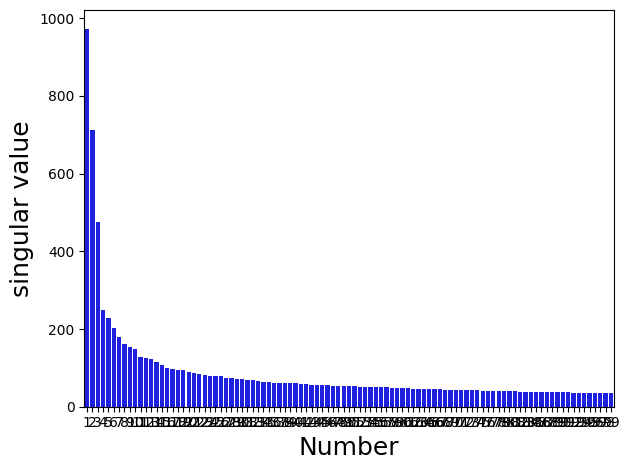

In [ ]:
import seaborn as sns
sns.barplot(x=list(range(1,100)),
            y=s[0:99], color="blue")  # first 100 singular
plot.xlabel('Number', fontsize=18)
plot.ylabel('singular value', fontsize=18)
plot.tight_layout()



Text(0, 0.5, 'Variance')

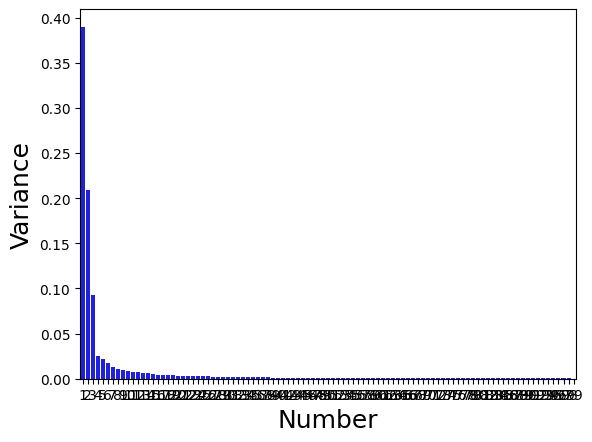

In [ ]:
import seaborn as sns
sns.barplot(x=list(range(1,100)),
            y=var_explained[0:99], color="blue")  # first 100 singular
plot.xlabel('Number', fontsize=18)
plot.ylabel('Variance', fontsize=18)


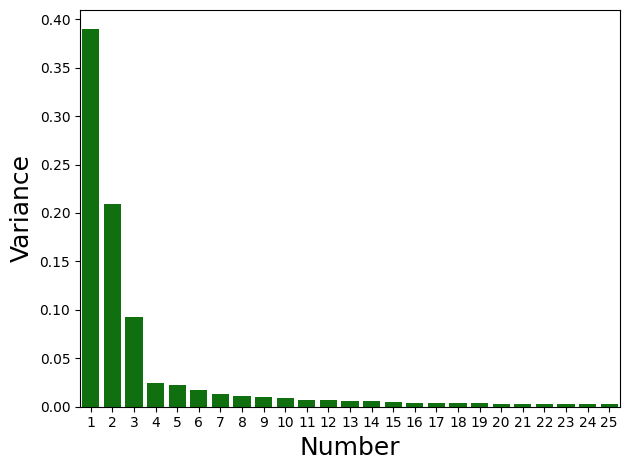

In [ ]:
import seaborn as sns
sns.barplot(x=list(range(1,26)),
            y=var_explained[0:25], color="green")  # first 25 singular
plot.xlabel('Number', fontsize=18)
plot.ylabel('Variance', fontsize=18)
plot.tight_layout()


As we are goind to right we are going less variance

Size of U, D, V is 5930, 5, 10240, respectively 
Total required information is  16175
While actual size is  2428928


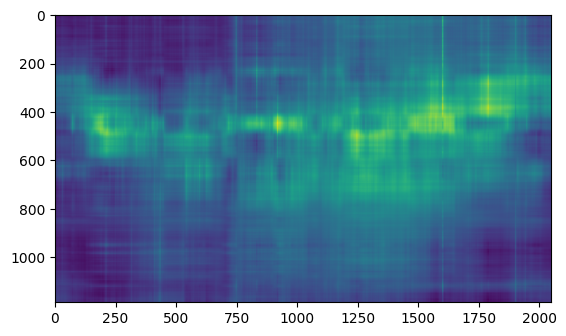

In [ ]:
# Reconstruction with top 5 singular values
num_components = 5
reconst_img_5 = np.array(U[:,:num_components]).dot(np.diag(s[:num_components]).dot(np.array(V[:num_components,:])))
plot.imshow(reconst_img_5)
Size_of_U=U[:,:num_components].size
Size_of_V=V[:num_components,:].size
Size_of_D=s[:num_components].size
print('Size of U, D, V is {}, {}, {}, respectively '.format(Size_of_U, Size_of_D, Size_of_V))
print('Total required information is ', Size_of_U+Size_of_D+Size_of_V)
print('While actual size is ', img_mat.size )

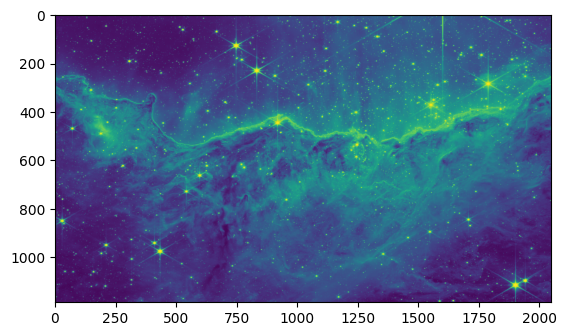

In [ ]:
plot.imshow(img_mat_scaled)

Size of U, D, V is 29650, 25, 51200, respectively 
Total required information is  80875
While actual size is  2428928


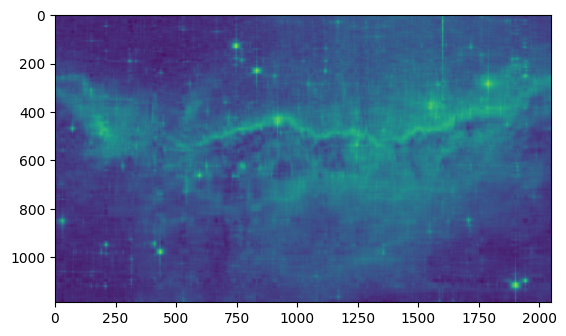

In [ ]:
# Reconstruction with top 25 singular values
num_components = 25
reconst_img_25 = np.array(U[:,:num_components]).dot(np.diag(s[:num_components]).dot(np.array(V[:num_components,:])))
plot.imshow(reconst_img_25)
Size_of_U=U[:,:num_components].size
Size_of_V=V[:num_components,:].size
Size_of_D=s[:num_components].size
print('Size of U, D, V is {}, {}, {}, respectively '.format(Size_of_U, Size_of_D, Size_of_V))
print('Total required information is ', Size_of_U+Size_of_D+Size_of_V)
print('While actual size is ', img_mat.size )

Size of U, D, V is 118600, 100, 204800, respectively 
Total required information is  323500
While actual size is  2428928


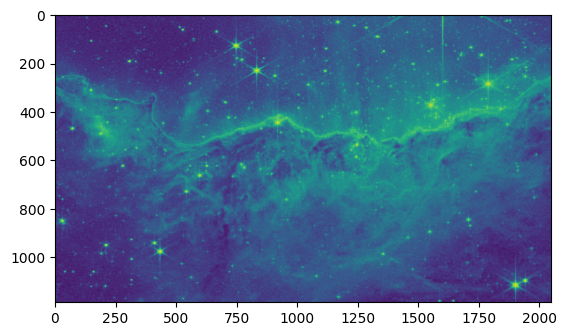

In [ ]:
# Reconstruction with top 100 singular values
num_components = 100
reconst_img_100 = np.array(U[:,:num_components]).dot(np.diag(s[:num_components]).dot(np.array(V[:num_components,:])))
plot.imshow(reconst_img_100)
Size_of_U=U[:,:num_components].size
Size_of_V=V[:num_components,:].size
Size_of_D=s[:num_components].size
print('Size of U, D, V is {}, {}, {}, respectively '.format(Size_of_U, Size_of_D, Size_of_V))
print('Total required information is ', Size_of_U+Size_of_D+Size_of_V)
print('While actual size is ', img_mat.size )

Size of U, D, V is 296500, 250, 512000, respectively 
Total required information is  808750
While actual size is  2428928


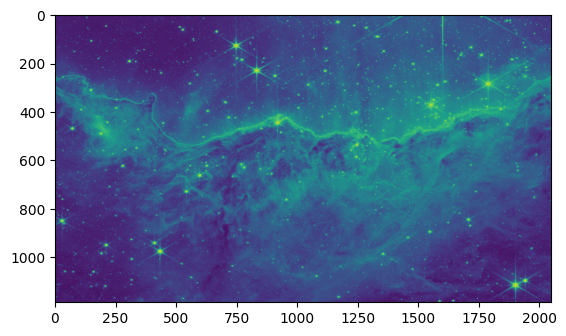

In [ ]:
# Reconstruction with top 250 singular values
num_components = 250
reconst_img_250 = np.array(U[:,:num_components]).dot(np.diag(s[:num_components]).dot(np.array(V[:num_components,:])))
plot.imshow(reconst_img_250)
Size_of_U=U[:,:num_components].size
Size_of_V=V[:num_components,:].size
Size_of_D=s[:num_components].size
print('Size of U, D, V is {}, {}, {}, respectively '.format(Size_of_U, Size_of_D, Size_of_V))
print('Total required information is ', Size_of_U+Size_of_D+Size_of_V)
print('While actual size is ', img_mat.size )

In [ ]:
# Reconstruction with top 450 singular values
num_components = 450
reconst_img_450 = np.array(U[:,:num_components]).dot(np.diag(s[:num_components]).dot(np.array(V[:num_components,:])))
plot.imshow(reconst_img_450)
Size_of_U=U[:,:num_components].size
Size_of_V=V[:num_components,:].size
Size_of_D=s[:num_components].size
print('Size of U, D, V is {}, {}, {}, respectively '.format(Size_of_U, Size_of_D, Size_of_V))
print('Total required information is ', Size_of_U+Size_of_D+Size_of_V)
print('While actual size is ', img_mat.size )

In [ ]:
plot.imshow(img_mat_scaled)

In [ ]:
# Reconstruction with top 750 singular values
num_components = 700
reconst_img_750= np.array(U[:,:num_components]).dot(np.diag(s[:num_components]).dot(np.array(V[:num_components,:])))
plot.imshow(reconst_img_750)

Size_of_U=U[:,:num_components].size
Size_of_V=V[:num_components,:].size
Size_of_D=s[:num_components].size
print('Size of U, D, V is {}, {}, {}, respectively '.format(Size_of_U, Size_of_D, Size_of_V))
print('Total required information is ', Size_of_U+Size_of_D+Size_of_V)
print('While actual size is ', img_mat.size )

In [ ]:
img_mat_scaled = (img_mat- img_mat.mean())/img_mat.std()
A=img_mat_scaled
#One has to first estimte A^T A

AtA = A.T @ A
# estimate eigenvalue decomposition of AT  A to get V and Sigma

eigvals, V = np.linalg.eig(AtA)

# Sort the eigenvalues and corresponding eigenvectors
sorted_indices = np.argsort(eigvals)[::-1]
eigvals = eigvals[sorted_indices]
V = V[:, sorted_indices]

# Step 3: Singular values are the square roots of the eigenvalues
Sigma = np.sqrt(eigvals)

# Step 4: Compute U from A * V * Sigma^(-1)
U = A @ V @ np.linalg.inv(np.diag(Sigma))

# U, Sigma, V.T now represent the SVD


#One can also use  *scipy* for this.


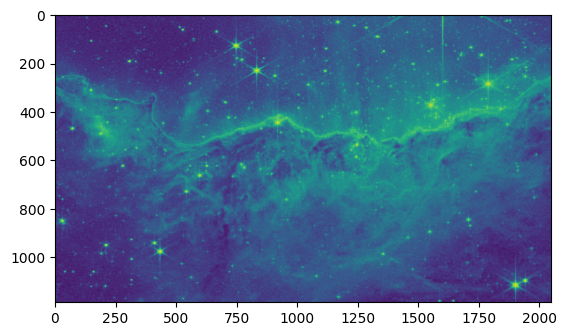

In [ ]:
from scipy.linalg import svd

U, Sigma, VT = svd(img_mat_scaled, full_matrices=False)
n_components = 100  # Number of singular values to keep
U_reduced = U[:, :n_components]
Sigma_reduced = np.diag(Sigma[:n_components])
VT_reduced = VT[:n_components, :]

recon_image = np.dot(U_reduced, np.dot(Sigma_reduced, VT_reduced))

plot.imshow(recon_image)



# Another way is to use sklearn

but remember  TruncatedSVD performs dimensionality reduction but doesn't compute the full SVD decomposition, while **np.linalg.svd** does this.
This result in low qualtiy of Image

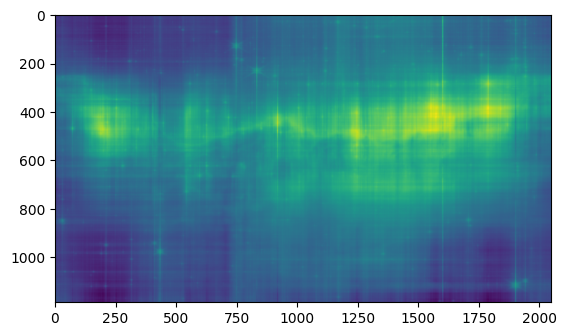

In [ ]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=100)
U = svd.fit_transform(img_mat_scaled)  # U * Sigma
Sigma = svd.singular_values_  # Singular values
VT = svd.components_  # VT

reco_image = np.dot(U, np.dot(np.diag(Sigma), VT))

plot.imshow(reco_image)